In [1]:
import pandas as pd

df = pd.read_csv('/kaggle/input/data-img-fake-real/features_handcraft_pca.csv')


In [2]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3417 entries, 0 to 3416
Columns: 513 entries, 0 to label
dtypes: float64(513)
memory usage: 13.4 MB


,0,1,2,3,4,5,6,7,8,9,...,503,504,505,506,507,508,509,510,511,label
0,-90.143431,-24.325168,5.851777,-49.331746,-45.560314,-57.787939,24.613754,-20.833134,-24.139192,3.723929,...,-4.841529,-3.914853,4.214789,4.396488,3.769170,1.022109,-5.691521,-1.478762,0.298144,0.0
1,-246.943273,16.497613,34.934814,-15.258153,5.523398,5.003261,6.357868,11.544529,3.026625,-11.592451,...,1.904592,2.632372,1.466434,0.549755,-2.078533,0.170460,-0.719524,4.873636,7.263614,0.0
2,-29.619168,47.129363,-1.247367,-11.214669,23.692716,22.134369,48.866019,-20.062487,-8.746344,-2.411041,...,-2.165896,0.563015,-3.813871,-3.625718,5.172486,-2.983125,-0.630621,-8.458762,-3.439649,0.0
3,-149.058454,104.578247,8.831053,-28.702627,-11.762134,-9.241918,2.795985,1.464393,9.225152,18.131857,...,-2.092509,4.676365,6.444659,-9.122905,-6.758287,-2.809508,-0.914393,2.142329,-0.661095,1.0
4,-204.176077,-24.776721,-28.521355,22.169255,8.870100,-5.937461,-7.946820,26.743526,13.094676,-12.407232,...,0.646175,0.564471,1.317015,-0.338480,0.807122,0.310969,-0.848134,-1.369522,-0.327078,1.0


In [4]:
X = df.drop('label', axis=1)
y = df['label']

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np


In [5]:
Xh_train, Xh_test, yh_train, yh_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [8]:
pca_viz = PCA(n_components=2)
X_train_2d = pca_viz.fit_transform(Xh_train)
X_test_2d = pca_viz.transform(Xh_test)



In [11]:


# 2. Huấn luyện SVM trên không gian 2D
svm_viz = SVC(kernel='rbf', C=1, gamma='scale')
svm_viz.fit(X_train_2d, yh_train)

SVC(C=1)

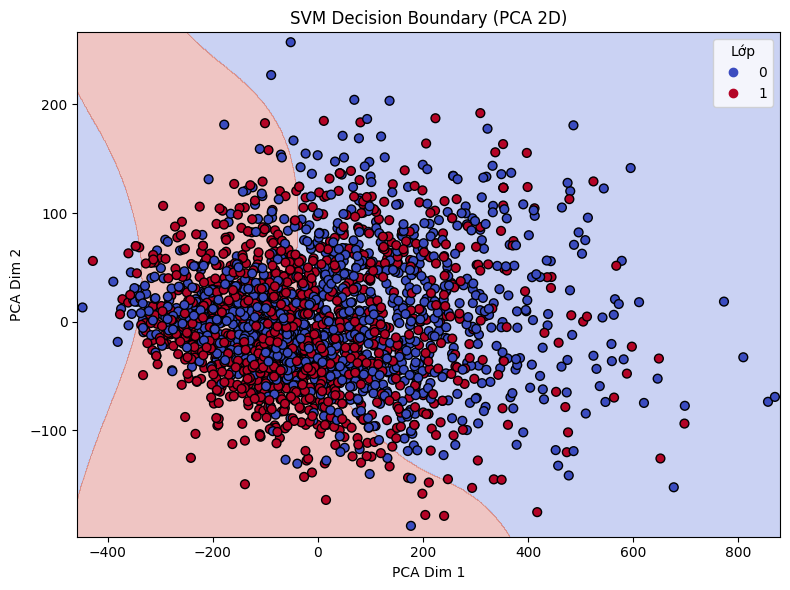

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split



# === 4. Hàm vẽ ranh giới đơn giản & nhẹ RAM
def plot_svm_boundary(model, X, y):
    h = 1.0  # bước lưới lớn để nhẹ RAM
    x_min, x_max = X[:, 0].min() - 10, X[:, 0].max() + 10
    y_min, y_max = X[:, 1].min() - 10, X[:, 1].max() + 10
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, cmap='coolwarm', alpha=0.3)
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k', s=40)
    plt.xlabel("PCA Dim 1")
    plt.ylabel("PCA Dim 2")
    plt.title("SVM Decision Boundary (PCA 2D)")
    plt.legend(*scatter.legend_elements(), title="Lớp")
    plt.tight_layout()
    plt.show()

# === 5. Gọi hàm
plot_svm_boundary(svm_viz, X_train_2d, yh_train)


# Logistic

In [ ]:
lgt_model = LogisticRegression(solver='newton-cholesky')
lgt_model.fit(Xh_train,yh_train)
y_pred = lgt_model.predict(Xh_test)

print(classification_report(yh_test, y_pred))
ConfusionMatrixDisplay(confusion_matrix(yh_test,y_pred),display_labels=['fake','real']).plot()


## cross-validation-lgt

In [ ]:
from sklearn.model_selection import cross_val_score, KFold
import numpy as np

lgt_model = LogisticRegression(solver='newton-cholesky')

kf = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(lgt_model, Xh_train, yh_train, cv=kf, scoring='accuracy')

print(f"Accuracy từng fold: {scores}")
print(f"Mean accuracy: {np.mean(scores):.4f}")


# SVM

              precision    recall  f1-score   support

         0.0       0.82      0.86      0.84       517
         1.0       0.86      0.81      0.83       509

    accuracy                           0.84      1026
   macro avg       0.84      0.84      0.84      1026
weighted avg       0.84      0.84      0.84      1026



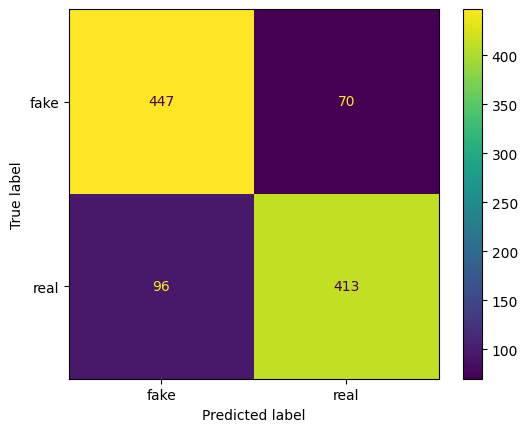

In [52]:
from sklearn.svm import SVC

svm_model = SVC(kernel='rbf', C=1, gamma='scale')  


svm_model.fit(Xh_train, yh_train)

y_pred = svm_model.predict(Xh_test)

print(classification_report(yh_test, y_pred))
ConfusionMatrixDisplay(confusion_matrix(yh_test, y_pred), display_labels=['fake', 'real']).plot()


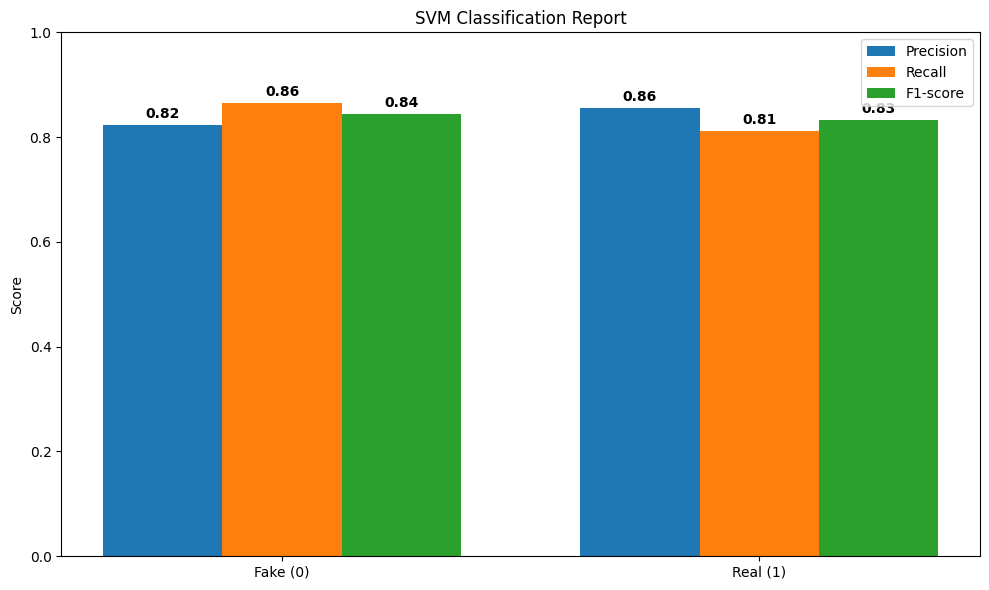

In [25]:
import matplotlib.pyplot as plt
import numpy as np

report = classification_report(yh_test, y_pred, output_dict=True)

labels = ['Fake', 'Real']
precision = [report['0.0']['precision'], report['1.0']['precision']]
recall = [report['0.0']['recall'], report['1.0']['recall']]
f1_score = [report['0.0']['f1-score'], report['1.0']['f1-score']]

x = np.arange(len(labels))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width, precision, width, label='Precision')
bars2 = ax.bar(x, recall, width, label='Recall')
bars3 = ax.bar(x + width, f1_score, width, label='F1-score')

ax.set_ylabel('Score')
ax.set_title('SVM Classification Report')
ax.set_xticks(x)
ax.set_xticklabels(['Fake (0)', 'Real (1)'])
ax.set_ylim(0, 1)
ax.legend()

# Ghi số liệu lên từng cột
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
# plt.grid()
plt.show()


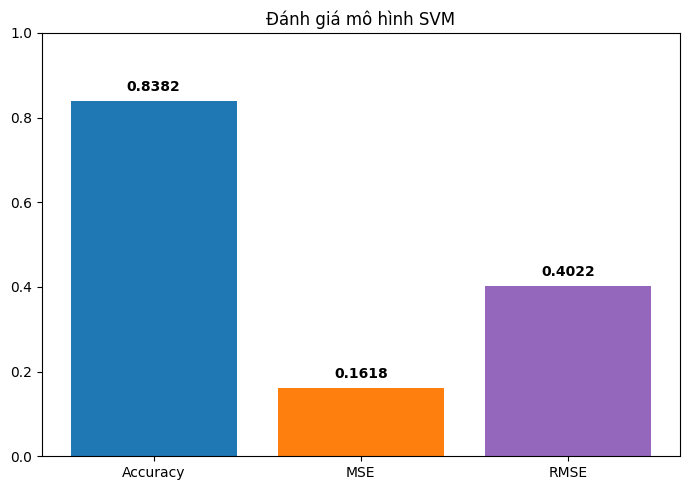

In [53]:
from sklearn.metrics import accuracy_score, mean_squared_error

accuracy_svm = accuracy_score(yh_test, y_pred)
mse_svm = mean_squared_error(yh_test, y_pred)
rmse_svm = np.sqrt(mse_svm)

# Vẽ biểu đồ
metrics = ['Accuracy', 'MSE', 'RMSE']
values = [accuracy_svm, mse_svm, rmse_svm]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(metrics, values, color=['tab:blue', 'tab:orange', 'tab:purple'])

# Ghi số liệu lên từng cột
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.4f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 5),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Đánh giá mô hình SVM')
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

Best params: {'C': 10, 'gamma': 'scale'}
              precision    recall  f1-score   support

         0.0       0.83      0.83      0.83       517
         1.0       0.83      0.83      0.83       509

    accuracy                           0.83      1026
   macro avg       0.83      0.83      0.83      1026
weighted avg       0.83      0.83      0.83      1026



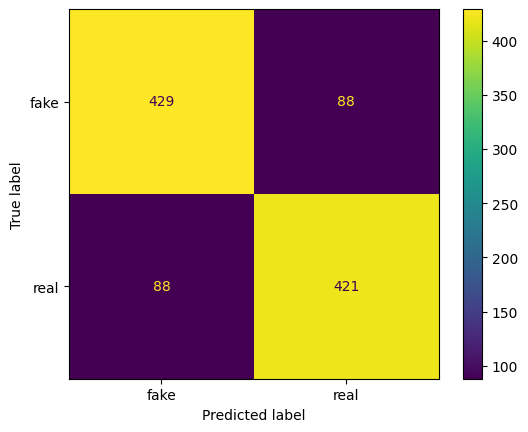

In [48]:
from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(
    estimator=SVC(),
    param_grid={'C': [0.1, 1, 10], 'gamma': [0.01, 0.1, 'scale', 0.001]},
    cv=5,
    n_jobs=-1  
)
grid.fit(Xh_train, yh_train)
print("Best params:", grid.best_params_)

best_svm = grid.best_estimator_
y_pred = best_svm.predict(Xh_test)

print(classification_report(yh_test, y_pred))

ConfusionMatrixDisplay(confusion_matrix(yh_test, y_pred), display_labels=['fake', 'real']).plot()

In [15]:
best_svm

SVC(C=10, gamma=0.01)

In [22]:
model_from_grid = best_svm
model_recreated = SVC(C=1, gamma='scale')
model_recreated.fit(Xh_train, yh_train)

y_pred = model_recreated.predict(Xh_test)

print(classification_report(yh_test, y_pred))

ConfusionMatrixDisplay(confusion_matrix(yh_test, y_pred), display_labels=['fake', 'real']).plot()


NameError: name 'best_svm' is not defined

In [33]:
print("🔍 Từ GridSearchCV:", model_from_grid.get_params())
print("🧪 Tự tạo:", model_recreated.get_params())


🔍 Từ GridSearchCV: {'C': 10, 'break_ties': False, 'cache_size': 200, 'class_weight': None, 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 'scale', 'kernel': 'rbf', 'max_iter': -1, 'probability': False, 'random_state': None, 'shrinking': True, 'tol': 0.001, 'verbose': False}
🧪 Tự tạo: {'C': 10, 'break_ties': False, 'cache_size': 200, 'class_weight': None, 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 'scale', 'kernel': 'rbf', 'max_iter': -1, 'probability': False, 'random_state': None, 'shrinking': True, 'tol': 0.001, 'verbose': False}


In [27]:
Xh_train, Xh_test, yh_train, yh_test = train_test_split(X, y, test_size=0.3, random_state=42)

              precision    recall  f1-score   support

         0.0       0.53      1.00      0.69       517
         1.0       1.00      0.11      0.19       509

    accuracy                           0.56      1026
   macro avg       0.77      0.55      0.44      1026
weighted avg       0.76      0.56      0.45      1026



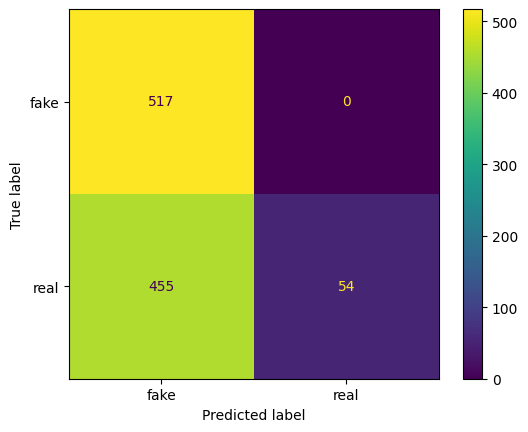

In [29]:
print(classification_report(yh_test, y_pred))

ConfusionMatrixDisplay(confusion_matrix(yh_test, y_pred), display_labels=['fake', 'real']).plot()

In [13]:
import joblib

joblib.dump(best_svm,'svm_model_best.pkl')

['svm_model_best.pkl']

              precision    recall  f1-score   support

         0.0       0.53      1.00      0.69       517
         1.0       1.00      0.11      0.19       509

    accuracy                           0.56      1026
   macro avg       0.77      0.55      0.44      1026
weighted avg       0.76      0.56      0.45      1026



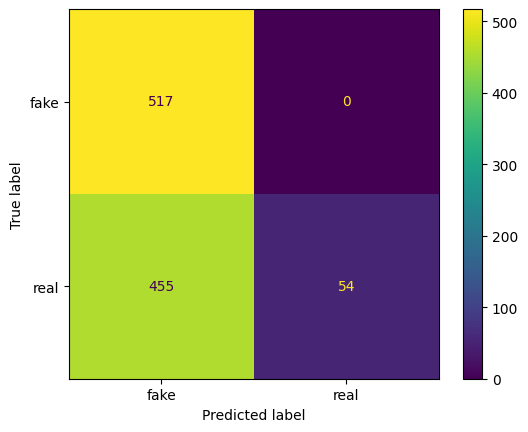

In [23]:
from sklearn.svm import SVC

svm_model = SVC(C=10, gamma=0.01)  


svm_model.fit(Xh_train, yh_train)

y_pred = svm_model.predict(Xh_test)

print(classification_report(yh_test, y_pred))
ConfusionMatrixDisplay(confusion_matrix(yh_test, y_pred), display_labels=['fake', 'real']).plot()


=== LinearSVC ===
              precision    recall  f1-score   support

         0.0       0.73      0.75      0.74       517
         1.0       0.73      0.71      0.72       509

    accuracy                           0.73      1026
   macro avg       0.73      0.73      0.73      1026
weighted avg       0.73      0.73      0.73      1026



/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


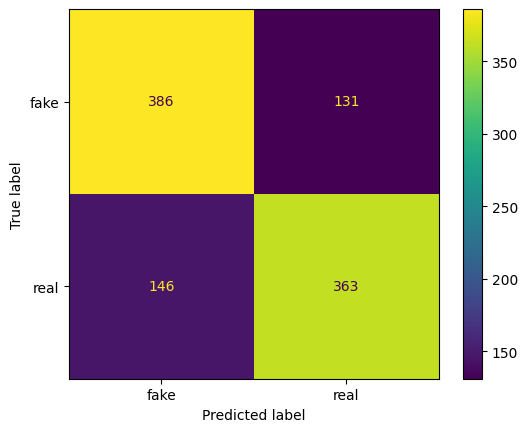

In [7]:
from sklearn.svm import LinearSVC

linear_svm = LinearSVC(C=1, max_iter=10000)
linear_svm.fit(Xh_train, yh_train)
y_pred = linear_svm.predict(Xh_test)

print("=== LinearSVC ===")
print(classification_report(yh_test, y_pred))
ConfusionMatrixDisplay(confusion_matrix(yh_test, y_pred), display_labels=['fake', 'real']).plot()


In [ ]:
svm_poly = SVC(kernel='poly', degree=1, C=5, gamma=1)
svm_poly.fit(Xh_train, yh_train)
y_pred_poly = svm_poly.predict(Xh_test)

print("=== Polynomial Kernel ===")
print(classification_report(yh_test, y_pred_poly))
ConfusionMatrixDisplay(confusion_matrix(yh_test, y_pred_poly), display_labels=['fake', 'real']).plot()


## save-model-svm

In [ ]:
import joblib

joblib.dump(svm_model,'svm_model.pkl')

## grid-search

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],   
    'gamma': ['scale'],           
    'kernel': ['rbf']              
}

#GridSearchCV
grid = GridSearchCV(
    SVC(), 
    param_grid, 
    cv=10,             
    verbose=2,        
    n_jobs=-1         
)

grid.fit(Xh_train, yh_train)

print("best parameters:", grid.best_params_)

best_svm = grid.best_estimator_
y_pred = best_svm.predict(Xh_test)

print(classification_report(yh_test, y_pred))

ConfusionMatrixDisplay(confusion_matrix(yh_test, y_pred), display_labels=['fake', 'real']).plot()


# Random Forest

              precision    recall  f1-score   support

         0.0       0.81      0.82      0.81       517
         1.0       0.81      0.80      0.81       509

    accuracy                           0.81      1026
   macro avg       0.81      0.81      0.81      1026
weighted avg       0.81      0.81      0.81      1026



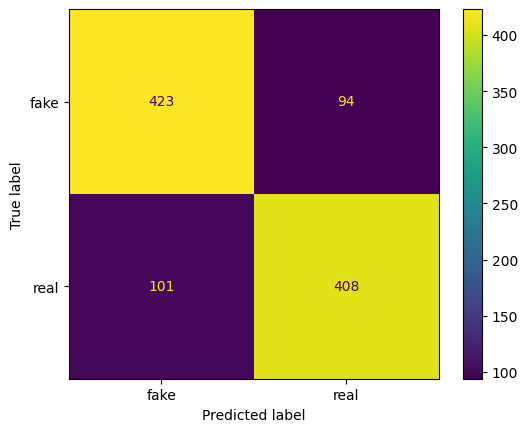

In [54]:
from sklearn.ensemble import RandomForestClassifier



rf_model = RandomForestClassifier(max_depth = 20, n_estimators = 200, random_state=42)

rf_model.fit(Xh_train, yh_train)

y_pred = rf_model.predict(Xh_test)

print(classification_report(yh_test, y_pred))

ConfusionMatrixDisplay(confusion_matrix(yh_test, y_pred), display_labels=['fake', 'real']).plot()


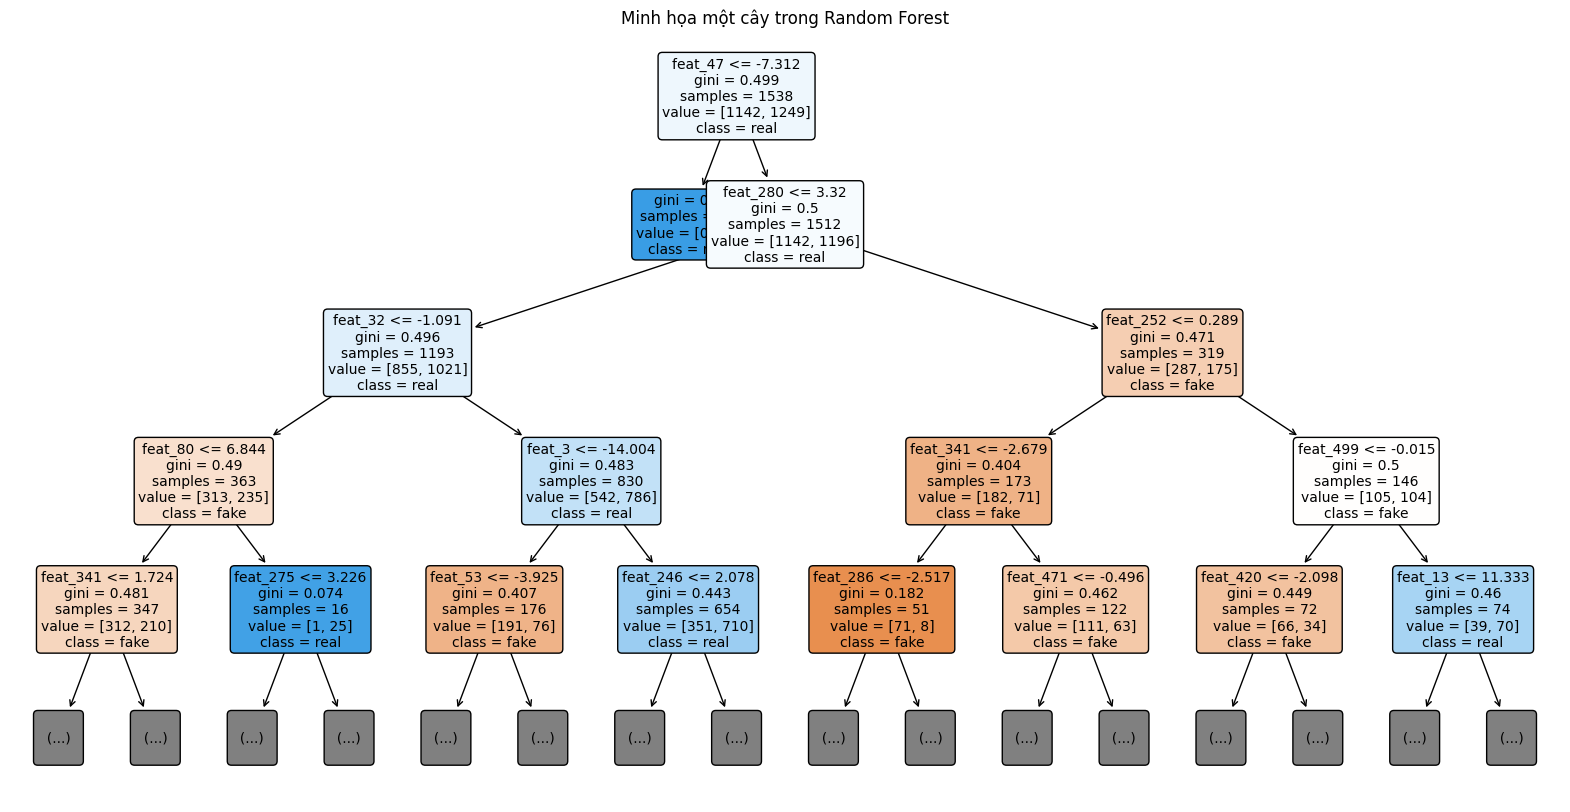

In [9]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# === Chọn 1 cây từ Random Forest
estimator = rf_model.estimators_[0]  # Cây đầu tiên trong rừng

# === Vẽ cây quyết định
plt.figure(figsize=(20, 10))
plot_tree(estimator,
          feature_names=[f'feat_{i}' for i in range(Xh_train.shape[1])],
          class_names=['fake', 'real'],
          filled=True,
          max_depth=4,     # Giới hạn độ sâu để dễ nhìn
          rounded=True,
          fontsize=10)
plt.title("Minh họa một cây trong Random Forest")
plt.show()


## grid-search

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Hyperparameters: {'max_depth': 20, 'n_estimators': 200}
              precision    recall  f1-score   support

        fake       0.81      0.82      0.81       517
        real       0.81      0.80      0.81       509

    accuracy                           0.81      1026
   macro avg       0.81      0.81      0.81      1026
weighted avg       0.81      0.81      0.81      1026



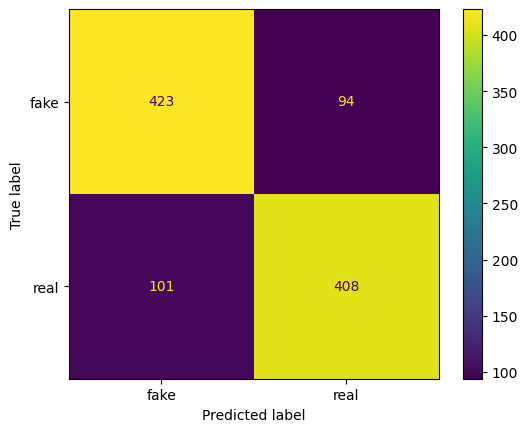

In [27]:
from sklearn.model_selection import GridSearchCV


param_grid = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [20, 50, 100, 150]
}

rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5, n_jobs=-1,
    verbose=2)
grid_search.fit(Xh_train, yh_train)

# model tốt nhất
best_rf = grid_search.best_estimator_
print("Best Hyperparameters:", grid_search.best_params_)

y_pred = best_rf.predict(Xh_test)
print(classification_report(yh_test, y_pred, target_names=['fake', 'real']))
ConfusionMatrixDisplay(confusion_matrix(yh_test, y_pred), display_labels=['fake','real']).plot()



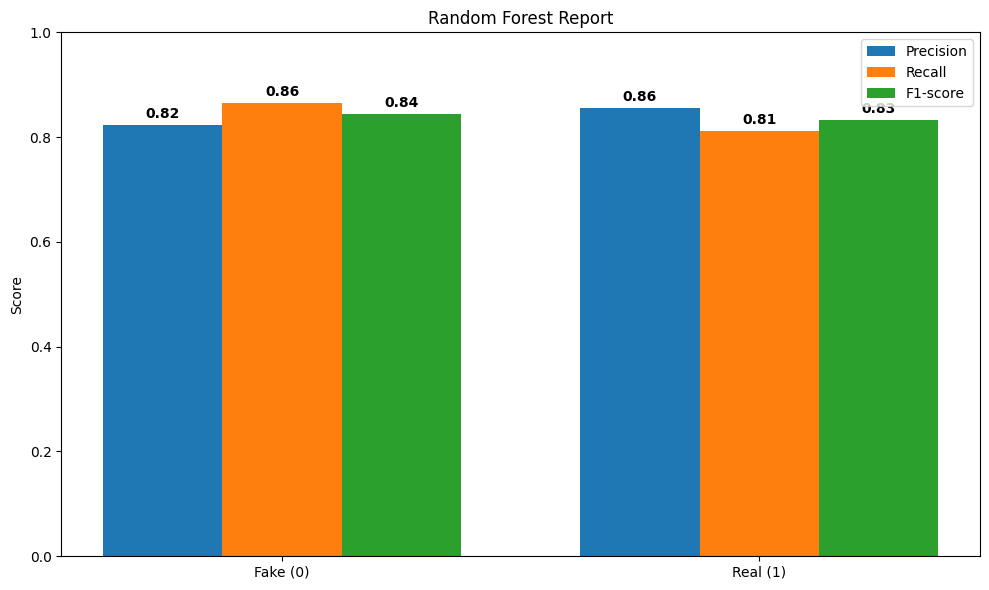

In [26]:
import matplotlib.pyplot as plt
import numpy as np

report = classification_report(yh_test, y_pred, output_dict=True)

labels = ['Fake', 'Real']
precision = [report['0.0']['precision'], report['1.0']['precision']]
recall = [report['0.0']['recall'], report['1.0']['recall']]
f1_score = [report['0.0']['f1-score'], report['1.0']['f1-score']]

x = np.arange(len(labels))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width, precision, width, label='Precision')
bars2 = ax.bar(x, recall, width, label='Recall')
bars3 = ax.bar(x + width, f1_score, width, label='F1-score')

ax.set_ylabel('Score')
ax.set_title('Random Forest Report')
ax.set_xticks(x)
ax.set_xticklabels(['Fake (0)', 'Real (1)'])
ax.set_ylim(0, 1)
ax.legend()

# Ghi số liệu lên từng cột
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
# plt.grid()
plt.show()


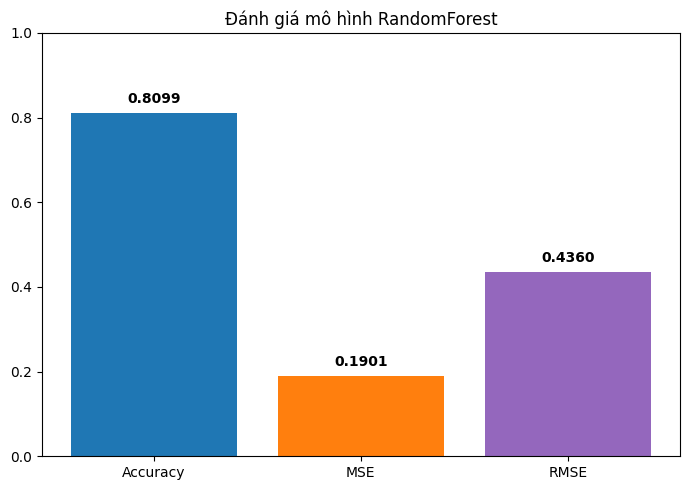

In [55]:
from sklearn.metrics import accuracy_score, mean_squared_error

accuracy_rf = accuracy_score(yh_test, y_pred)
mse_rf = mean_squared_error(yh_test, y_pred)
rmse_rf = np.sqrt(mse_rf)

# Vẽ biểu đồ
metrics = ['Accuracy', 'MSE', 'RMSE']
values = [accuracy_rf, mse_rf, rmse_rf]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(metrics, values, color=['tab:blue', 'tab:orange', 'tab:purple'])

# Ghi số liệu lên từng cột
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.4f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 5),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Đánh giá mô hình RandomForest')
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

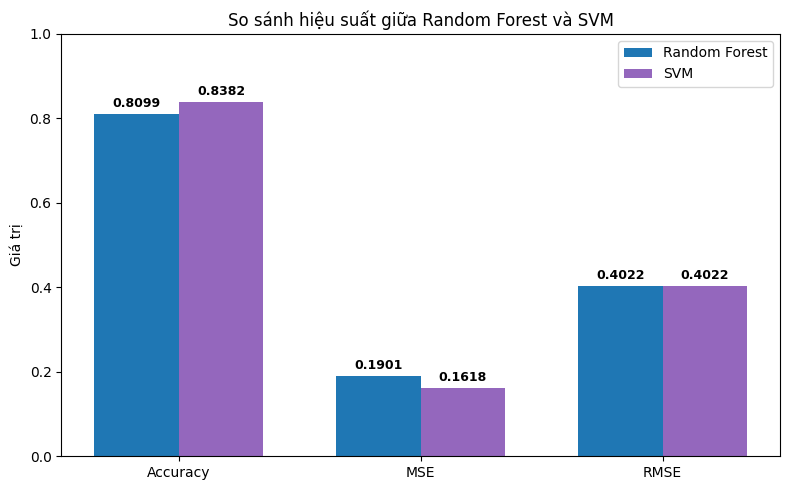

In [40]:
metrics = ['Accuracy', 'MSE', 'RMSE']
x = np.arange(len(metrics))
width = 0.35

svm_values = [accuracy_svm, mse_svm, rmse_svm]
rf_values = [accuracy_rf, mse_rf, rmse_rf]

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, rf_values, width, label='Random Forest', color='tab:blue')
bars2 = ax.bar(x + width/2, svm_values, width, label='SVM', color='tab:purple')

# Ghi giá trị lên cột
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

# Thiết lập biểu đồ
ax.set_ylabel('Giá trị')
ax.set_title('So sánh hiệu suất giữa Random Forest và SVM')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1)
ax.legend()

plt.tight_layout()
plt.show()

# XGBoost

In [ ]:
import numpy as np
import pandas as pd
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

xgb = XGBClassifier(
    n_estimators=100,         # Số cây 
    max_depth=6,              # Độ sâu của cây
    learning_rate=0.1,        
    subsample=0.8,            # Tỷ lệ mẫu mỗi cây
    colsample_bytree=0.8,     # Tỷ lệ cột mỗi cây
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

xgb.fit(Xh_train, yh_train)

y_pred = xgb.predict(Xh_test)

print(classification_report(yh_test, y_pred))
ConfusionMatrixDisplay(confusion_matrix(yh_test, y_pred), display_labels=['fake', 'real']).plot()

# MLP

In [ ]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(hidden_layer_sizes=(512, 240, 128), 
                    activation='relu',
                    solver='adam',
                    random_state=42,
                    max_iter=500)
mlp.fit(Xh_train, yh_train)

y_pred = mlp.predict(Xh_test)

print(classification_report(yh_test, y_pred, target_names=['fake', 'real']))
ConfusionMatrixDisplay(confusion_matrix(yh_test, y_pred), display_labels=['fake','real']).plot()

In [42]:
import pandas as pd
import numpy as np
from cvxopt import matrix, solvers

import joblib
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Custom SVM implementation
class CustomSVM:
    def __init__(self, C=1.0, gamma='scale', learning_rate=0.01, max_iterations=1000):
        self.C = C
        self.gamma = gamma
        self.learning_rate = learning_rate
        self.max_iterations = max_iterations
        self.weights = None
        self.bias = None
        self.support_vectors_ = None
        self.X_train = None
        self.y_train = None
        self.support_vector_weights_ = None
        self.support_vector_labels_ = None

    def rbf_kernel(self, X1, X2):
        # Convert pandas DataFrame/Series to NumPy array if necessary
        if isinstance(X1, (pd.DataFrame, pd.Series)):
            X1 = X1.to_numpy()
        if isinstance(X2, (pd.DataFrame, pd.Series)):
            X2 = X2.to_numpy()

        # Tính kernel RBF: exp(-gamma * ||x1 - x2||^2)
        gamma = self.gamma
        if gamma == 'scale':
            gamma = 1.0 / (X1.shape[1] * np.var(X1))
        
        # Ensure X1 and X2 are 2D arrays
        if X1.ndim == 1:
            X1 = X1.reshape(1, -1)
        if X2.ndim == 1:
            X2 = X2.reshape(1, -1)
        
        squared_dist = np.sum(X1**2, axis=1).reshape(-1, 1) + np.sum(X2**2, axis=1) - 2 * np.dot(X1, X2.T)
        return np.exp(-gamma * squared_dist)

    # def fit(self, X, y):
    #     # Convert pandas DataFrame/Series to NumPy array
    #     if isinstance(X, (pd.DataFrame, pd.Series)):
    #         X = X.to_numpy()
    #     if isinstance(y, (pd.DataFrame, pd.Series)):
    #         y = y.to_numpy()

    #     n_samples, n_features = X.shape
    #     # Chuyển nhãn thành {-1, 1}
    #     y_ = np.where(y == 0, -1, 1)
        
    #     # Khởi tạo weights và bias
    #     self.weights = np.zeros(n_samples)  # Dual coefficients (alpha)
    #     self.bias = 0.0
        
    #     # Lưu dữ liệu để tính kernel
    #     self.X_train = X
    #     self.y_train = y_
        
    #     # Gradient descent để tối ưu hóa
    #     for _ in range(self.max_iterations):
    #         # Tính dự đoán
    #         K = self.rbf_kernel(X, X)
    #         y_pred = np.sign(np.dot(K, self.weights * y_) + self.bias)
            
    #         # Cập nhật weights (alpha)
    #         for i in range(n_samples):
    #             if y_[i] * (np.dot(K[i], self.weights * y_) + self.bias) <= 1:
    #                 self.weights[i] += self.learning_rate * (self.C * y_[i] - (self.weights[i] * y_[i] * K[i, i]))
    #             else:
    #                 self.weights[i] -= self.learning_rate * self.weights[i]
            
    #         # Cập nhật bias
    #         self.bias += self.learning_rate * np.mean(y_ - np.dot(K, self.weights * y_))
        
    #     # Lưu support vectors
    #     sv_indices = np.abs(self.weights) > 1e-5
    #     self.support_vectors_ = X[sv_indices]
    #     self.support_vector_labels_ = y_[sv_indices]
    #     self.support_vector_weights_ = self.weights[sv_indices]
    def fit(self, X, y):
        # Convert to numpy
        if isinstance(X, (pd.DataFrame, pd.Series)):
            X = X.to_numpy()
        if isinstance(y, (pd.DataFrame, pd.Series)):
            y = y.to_numpy()
            
        n_samples, n_features = X.shape
        y_ = np.where(y == 0, -1, 1)

        self.X_train = X
        self.y_train = y_

        # Tính kernel matrix K
        K = self.rbf_kernel(X, X)

        # Setup cho QP
        P = matrix(np.outer(y_, y_) * K)
        q = matrix(-np.ones(n_samples))
        
        # Gx ≤ h
        G_std = np.diag(-np.ones(n_samples))       # -alpha ≤ 0
        h_std = np.zeros(n_samples)
        
        G_slack = np.diag(np.ones(n_samples))      # alpha ≤ C
        h_slack = np.ones(n_samples) * self.C
        
        G = matrix(np.vstack((G_std, G_slack)))
        h = matrix(np.hstack((h_std, h_slack)))

        # Ax = b (ràng buộc y^T * alpha = 0)
        A = matrix(y_.reshape(1, -1).astype('double'))
        b = matrix(np.zeros(1))

        # Giải bài toán QP
        solvers.options['show_progress'] = False
        solution = solvers.qp(P, q, G, h, A, b)

        alpha = np.ravel(solution['x'])

        # Lọc support vectors
        sv = alpha > 1e-5
        self.support_vector_weights_ = alpha[sv]
        self.support_vectors_ = X[sv]
        self.support_vector_labels_ = y_[sv]

        # Tính bias b
        K_sv = self.rbf_kernel(self.support_vectors_, self.support_vectors_)
        self.bias = np.mean(
            self.support_vector_labels_ - np.sum(
                self.support_vector_weights_ * self.support_vector_labels_[:, None] * K_sv, axis=0
            )
        )

    def predict(self, X):
        # Convert pandas DataFrame/Series to NumPy array
        if isinstance(X, (pd.DataFrame, pd.Series)):
            X = X.to_numpy()

        # Compute kernel between test data and support vectors (not all training data)
        K = self.rbf_kernel(X, self.support_vectors_)
        decision = np.dot(K, self.support_vector_weights_ * self.support_vector_labels_) + self.bias
        return np.where(np.sign(decision) == 1, 1, 0)



# Train Custom SVM
custom_svm = CustomSVM(C=1.0, gamma='scale', learning_rate=0.01, max_iterations=1000)
custom_svm.fit(Xh_train, yh_train)
custom_svm_pred = custom_svm.predict(Xh_test)




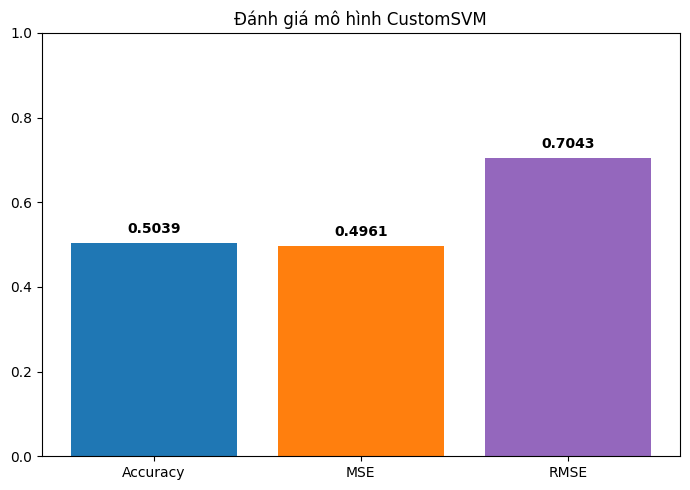

In [50]:
from sklearn.metrics import accuracy_score, mean_squared_error

accuracy_cs_svm = accuracy_score(yh_test, custom_svm_pred)
mse_cs_svm = mean_squared_error(yh_test, custom_svm_pred)
rmse_cs_svm = np.sqrt(mse_cs_svm)

# Vẽ biểu đồ
metrics = ['Accuracy', 'MSE', 'RMSE']
values = [accuracy_cs_svm, mse_cs_svm, rmse_cs_svm]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(metrics, values, color=['tab:blue', 'tab:orange', 'tab:purple'])

# Ghi số liệu lên từng cột
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.4f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 5),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Đánh giá mô hình CustomSVM')
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

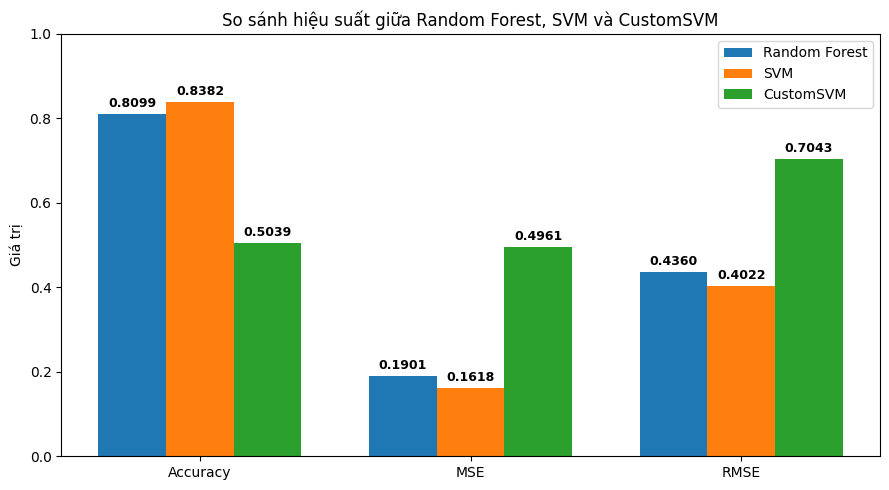

In [56]:
metrics = ['Accuracy', 'MSE', 'RMSE']
x = np.arange(len(metrics))
width = 0.25

svm_values = [accuracy_svm, mse_svm, rmse_svm]
rf_values = [accuracy_rf, mse_rf, rmse_rf]
custom_svm_values = [accuracy_cs_svm, mse_cs_svm, rmse_cs_svm]
fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width, rf_values, width, label='Random Forest')
bars2 = ax.bar(x, svm_values, width, label='SVM')
bars3 = ax.bar(x + width, custom_svm_values, width, label='CustomSVM')

# Ghi giá trị lên cột
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

# Thiết lập biểu đồ
ax.set_ylabel('Giá trị')
ax.set_title('So sánh hiệu suất giữa Random Forest, SVM và CustomSVM')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1)
ax.legend()

plt.tight_layout()
plt.show()